# PERMEABILITY MEASUREMENT WITH GAS PERMEAMETER 

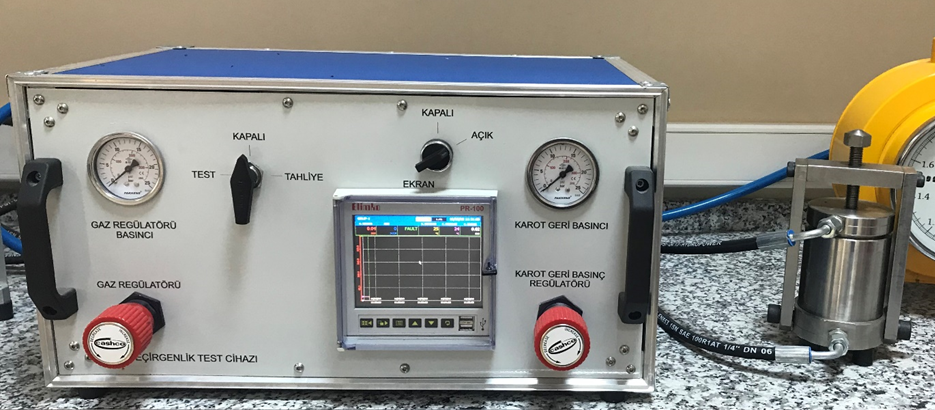


--------------------------------------------------
GAS PERMEABILITY EXPERIMENT RESULTS
--------------------------------------------------

   P1 (bar-g)  P2 (bar-g)  Q (cm3/min)  Q (cm3/s)  P1 abs (atm)  P2 abs (atm)  \
0        0.53         0.0           18      0.300          1.53           1.0   
1        1.34         0.0           58      0.967          2.34           1.0   
2        2.72         0.0          163      2.717          3.72           1.0   
3        5.38         0.0          490      8.167          6.38           1.0   

   Pm (atm)  kg (mD)  1/Pm (atm^-1)  
0     1.265    4.762          0.791  
1     1.670    4.597          0.599  
2     2.360    4.504          0.424  
3     3.690    4.378          0.271  

--------------------------------------------------
CORE SAMPLE INFORMATION
--------------------------------------------------
Well Name : FB-1907
Core No   : FB-1
Depth     : 2186 m

--------------------------------------------------
CORE DIMENSIONS
-------------

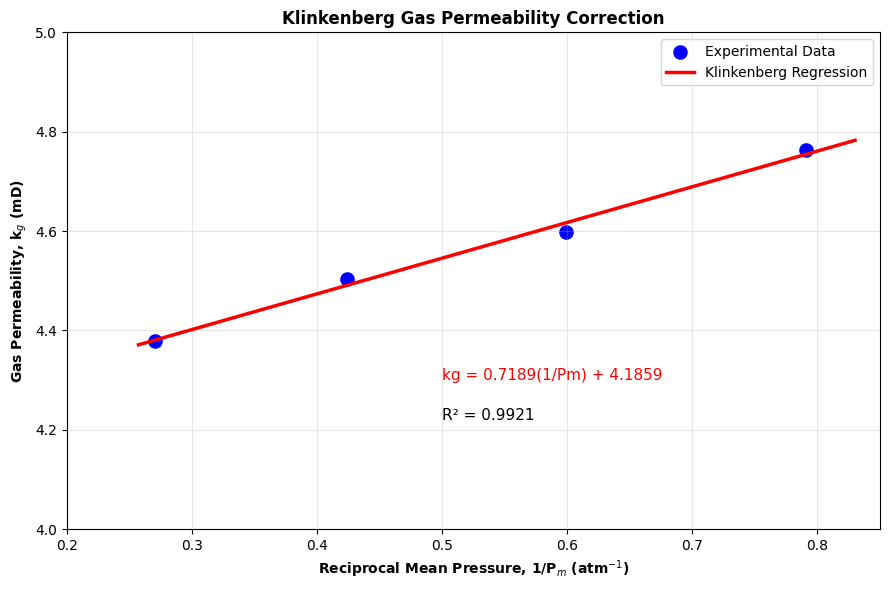

In [1]:
# -------------------------------------------------------------
# GAS PERMEABILITY MEASUREMENT WITH KLINKENBERG CORRECTION
# -------------------------------------------------------------
# Written by Sukru Merey
# Date: 16/05/2026
# -------------------------------------------------------------

"""
In this Python code, the absolute permeability of a core plug sample from the Southeastern Anatolia Region of Türkiye is 
measured using a gas permeameter device. Nitrogen (N₂) was used as the flowing gas in this study; however, helium is generally 
preferred because it minimizes gas–rock interactions. For accurate gas permeability measurements, correcting for the Klinkenberg 
effect is essential. Finally, the absolute permeability of the core plug sample was determined.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# -------------------------------------------------------------
# CORE SAMPLE INFORMATION
# -------------------------------------------------------------

well_name = "FB-1907"
core_no = "FB-1"

depth_m = 2186

# Core dimensions
length_cm = 6.600
diameter_cm = 3.750

# Gas viscosity (Nitrogen)
mu_cp = 0.01781

# Cross-sectional area
area_cm2 = np.pi * (diameter_cm**2) / 4

# -------------------------------------------------------------
# LABORATORY MEASUREMENTS
# -------------------------------------------------------------
# P1 : Inlet pressure (bar-g)
# P2 : Outlet pressure (bar-g)
# Q  : Flow rate (cm3/min)
# -------------------------------------------------------------

P1_bar_g = np.array([0.53, 1.34, 2.72, 5.38])

P2_bar_g = np.array([0.0, 0.0, 0.0, 0.0])

Q_cm3_min = np.array([18, 58, 163, 490])

# -------------------------------------------------------------
# PRESSURE CONVERSIONS
# -------------------------------------------------------------

# Atmospheric pressure
Patm_bar = 1.0

# Convert gauge pressure to absolute pressure
P1_abs = P1_bar_g + Patm_bar
P2_abs = P2_bar_g + Patm_bar

# Mean pressure
Pm = (P1_abs + P2_abs) / 2

# Reciprocal mean pressure
inverse_Pm = 1 / Pm

# -------------------------------------------------------------
# FLOW RATE CONVERSION
# -------------------------------------------------------------

# Convert cm3/min to cm3/s
Q_cm3_sec = Q_cm3_min / 60

# -------------------------------------------------------------
# GAS PERMEABILITY CALCULATION
# -------------------------------------------------------------
# Darcy equation for compressible gas flow:
#
#            2000 * μ * L * Q * Patm
# kg = ------------------------------------
#       A * (P1² - P2²)
#
# kg : gas permeability (mD)
# μ  : gas viscosity (cP)
# L  : sample length (cm)
# Q  : flow rate (cm3/s)
# A  : cross-sectional area (cm2)
# P1 : inlet pressure (atm)
# P2 : outlet pressure (atm)
# -------------------------------------------------------------

k_g = (
    2000
    * mu_cp
    * length_cm
    * Q_cm3_sec
    * 1.0
) / (
    area_cm2
    * (P1_abs**2 - P2_abs**2)
)

# -------------------------------------------------------------
# KLINKENBERG CORRECTION
# -------------------------------------------------------------
# kg = kl + (kl*b)*(1/Pm)
#
# y = mx + c
#
# slope     = kl*b
# intercept = kl
# -------------------------------------------------------------

slope, intercept, r_value, p_value, std_err = linregress(
    inverse_Pm,
    k_g
)

# Liquid permeability
k_liquid = intercept

# Klinkenberg slip factor
b = slope / intercept

# R²
r2 = r_value**2

# -------------------------------------------------------------
# CREATE RESULTS TABLE
# -------------------------------------------------------------

results = pd.DataFrame({

    "P1 (bar-g)": P1_bar_g,
    "P2 (bar-g)": P2_bar_g,

    "Q (cm3/min)": Q_cm3_min,
    "Q (cm3/s)": np.round(Q_cm3_sec, 3),

    "P1 abs (atm)": np.round(P1_abs, 3),
    "P2 abs (atm)": np.round(P2_abs, 3),

    "Pm (atm)": np.round(Pm, 3),

    "kg (mD)": np.round(k_g, 3),

    "1/Pm (atm^-1)": np.round(inverse_Pm, 3)

})

# -------------------------------------------------------------
# PRINT RESULTS
# -------------------------------------------------------------

print("\n--------------------------------------------------")
print("GAS PERMEABILITY EXPERIMENT RESULTS")
print("--------------------------------------------------\n")

print(results)

print("\n--------------------------------------------------")
print("CORE SAMPLE INFORMATION")
print("--------------------------------------------------")

print(f"Well Name : {well_name}")
print(f"Core No   : {core_no}")

print(f"Depth     : {depth_m} m")

print("\n--------------------------------------------------")
print("CORE DIMENSIONS")
print("--------------------------------------------------")

print(f"Diameter  : {diameter_cm:.3f} cm")
print(f"Length    : {length_cm:.3f} cm")

print(f"Area      : {area_cm2:.3f} cm²")

print("\n--------------------------------------------------")
print("GAS PROPERTIES")
print("--------------------------------------------------")

print(f"Gas Viscosity : {mu_cp:.5f} cP")

print("\n--------------------------------------------------")
print("KLINKENBERG RESULTS")
print("--------------------------------------------------")

print(f"Slope (m)                 = {slope:.4f}")

print(f"\033[1mAbsolute Permeability (k_abs) = {k_liquid:.3f} mD\033[0m")

print(f"Slip Factor (b)          = {b:.3f}")

print(f"R²                       = {r2:.4f}")

# -------------------------------------------------------------
# REGRESSION LINE
# -------------------------------------------------------------

x_line = np.linspace(
    min(inverse_Pm) * 0.95,
    max(inverse_Pm) * 1.05,
    100
)

y_line = slope * x_line + intercept

# -------------------------------------------------------------
# PLOT
# -------------------------------------------------------------

plt.figure(figsize=(9,6))

# Experimental data points
plt.scatter(
    inverse_Pm,
    k_g,
    color='blue',
    s=90,
    label='Experimental Data'
)

# Regression line
plt.plot(
    x_line,
    y_line,
    color='red',
    linewidth=2.5,
    label='Klinkenberg Regression'
)

# -------------------------------------------------------------
# EQUATION ON FIGURE
# -------------------------------------------------------------

plt.text(
    0.50,
    4.30,
    f"kg = {slope:.4f}(1/Pm) + {intercept:.4f}",
    fontsize=11,
    color='red'
)

plt.text(
    0.50,
    4.22,
    f"R² = {r2:.4f}",
    fontsize=11
)

# -------------------------------------------------------------
# AXES
# -------------------------------------------------------------

plt.xlabel(
    r"Reciprocal Mean Pressure, 1/P$_m$ (atm$^{-1}$)",
    fontweight='bold'
)

plt.ylabel(
    r"Gas Permeability, k$_g$ (mD)",
    fontweight='bold'
)

plt.title(
    "Klinkenberg Gas Permeability Correction",
    fontweight='bold'
)

# Axis limits
plt.xlim(0.20, 0.85)

plt.ylim(4.0, 5.0)

# Grid
plt.grid(alpha=0.3)

# Legend
plt.legend(frameon=True)

# Better spacing
plt.tight_layout()

# Show figure
plt.show()